# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Almas Ikramina
- **Email:** cdcc200d6x1676@student.devacademy.id
- **ID Dicoding:** CDCC200D6X1676

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1

Kategori produk apa yang memiliki performa penjualan terbaik dan terendah berdasarkan jumlah item terjual dan total nilai pembayaran?

- Pertanyaan 2

Bagaimana tren penjualan (jumlah order dan revenue) dari waktu ke waktu?

- Pertanyaan 3

Wilayah (state) mana yang memberikan kontribusi terbesar terhadap total transaksi?

## Import Semua Packages/Library yang Digunakan

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [233]:
# memuat dataset
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [234]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [235]:
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [236]:
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [237]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [238]:
product_category_df = pd.read_csv("product_category_name_translation.csv")
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [239]:
sellers_df = pd.read_csv("sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [240]:
geolocation_df = pd.read_csv("geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [241]:
order_reviews_df = pd.read_csv("order_reviews_dataset.csv")
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- Dataset yang digunakan terdiri dari beberapa tabel yang saling berelasi, seperti customers, orders, order_items, products, dan payments.
- Setiap tabel memiliki peran yang berbeda, misalnya:
  - customers untuk informasi pelanggan
  - orders untuk transaksi
  - order_items untuk detail produk dalam transaksi
- Data memiliki key utama seperti `customer_id`, `order_id`, dan `product_id` yang dapat digunakan untuk proses penggabungan (merge).
- Struktur data ini memungkinkan analisis yang lebih mendalam seperti analisis penjualan, perilaku pelanggan, dan performa produk.


### Assessing Data

#### Menilai tabel `customers_df`

In [242]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [243]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [244]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [245]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


#### Menilai tabel `orders_df`

In [246]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [247]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [248]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [249]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


#### Menilai tabel `order_items_df`

In [250]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [251]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [252]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [253]:
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


#### Menilai tabel `order_payments_df`

In [254]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [255]:
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [256]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


In [257]:
order_payments_df.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


#### Menilai tabel `products_df`

In [258]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [259]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [260]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [261]:
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


#### Menilai tabel `product_category_df`

In [262]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [263]:
product_category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [264]:
print("Jumlah duplikasi: ", product_category_df.duplicated().sum())

Jumlah duplikasi:  0


In [265]:
product_category_df.describe(include="all")

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


#### Menilai tabel `sellers_df`

In [266]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [267]:
sellers_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [268]:
print("Jumlah duplikasi: ", sellers_df.duplicated().sum())

Jumlah duplikasi:  0


In [269]:
sellers_df.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


#### Menilai tabel `geolocation_df`

In [270]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [271]:
geolocation_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [272]:
print("Jumlah duplikasi: ", geolocation_df.duplicated().sum())

Jumlah duplikasi:  261831


In [273]:
geolocation_df.describe(include="all")

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


#### Menilai tabel `order_reviews_df`

In [274]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [275]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [276]:
print("Jumlah duplikasi: ", order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


In [277]:
order_reviews_df.describe(include="all")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


**Insight:**
- Dataset customers_df, orders_df, order_items_df, order_payments_df, product_category_df, sellers_df tidak memiliki missing value dan tidak terdapat duplikasi data.
- Pada tabel orders_df terdapat missing value pada beberapa kolom seperti order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date.
- Pada tabel products_df terdapat missing value pada beberapa kolom seperti product_category_name dan atribut produk lainnya.
- Tabel geolocation_df memiliki jumlah data yang sangat besar dan terdapat banyak duplikasi data (lebih dari 200 ribu), sehingga perlu dilakukan pembersihan.
- Tabel order_reviews_df memiliki banyak missing value pada kolom review_comment_title dan review_comment_message.
- Beberapa kolom bertipe tanggal masih bertipe object, sehingga perlu diubah menjadi datetime untuk analisis lebih lanjut.

### Cleaning Data

#### Membersihkan tabel `customers_df`

##### Duplicate data

In [278]:
customers_df.duplicated().sum()

np.int64(0)

In [279]:
customers_df.drop_duplicates(inplace=True)

In [280]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


##### Missing values

In [281]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


#### Membersihkan tabel `orders_df`

##### Missing values

In [282]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


##### Memperbaiki tipe data

In [283]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [284]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


#### Membersihkan tabel `order_items_df`

##### Duplicate data

In [285]:
order_items_df.duplicated().sum()

np.int64(0)

In [286]:
order_items_df.drop_duplicates(inplace=True)

In [287]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


##### Memperbaiki tipe data

In [288]:
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

In [289]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


#### Membersihkan tabel `order_payments_df`

##### Duplicate data


In [290]:
order_payments_df.duplicated().sum()

np.int64(0)

In [291]:
order_payments_df.drop_duplicates(inplace=True)

In [292]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


##### Missing values

In [293]:
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


#### Membersihkan tabel `products_df`

##### Missing values

In [294]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


##### Menangani missing value pada `product_category_name`

In [295]:
products_df[products_df.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [296]:
products_df["product_category_name"].fillna("unknown", inplace=True)

/tmp/ipykernel_16099/3365687060.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_category_name"].fillna("unknown", inplace=True)


Menangani missing value pada atribut produk

In [297]:
products_df["product_name_lenght"].fillna(products_df["product_name_lenght"].median(), inplace=True)
products_df["product_description_lenght"].fillna(products_df["product_description_lenght"].median(), inplace=True)
products_df["product_photos_qty"].fillna(products_df["product_photos_qty"].median(), inplace=True)
products_df["product_weight_g"].fillna(products_df["product_weight_g"].median(), inplace=True)
products_df["product_length_cm"].fillna(products_df["product_length_cm"].median(), inplace=True)
products_df["product_height_cm"].fillna(products_df["product_height_cm"].median(), inplace=True)
products_df["product_width_cm"].fillna(products_df["product_width_cm"].median(), inplace=True)

/tmp/ipykernel_16099/3544497724.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_name_lenght"].fillna(products_df["product_name_lenght"].median(), inplace=True)
/tmp/ipykernel_16099/3544497724.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [298]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


##### Duplicate data

In [299]:
products_df.duplicated().sum()

np.int64(0)

In [300]:
products_df.drop_duplicates(inplace=True)

In [301]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


##### Membersihkan tabel `product_category_df`

##### Missing values

In [302]:
product_category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


##### Duplicate data

In [303]:
product_category_df.duplicated().sum()

np.int64(0)

In [304]:
product_category_df.drop_duplicates(inplace=True)

In [305]:
print("Jumlah duplikasi: ", product_category_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Tidak ditemukan duplikasi pada sebagian besar tabel yang digunakan, sehingga proses cleaning lebih difokuskan pada penanganan missing value dan perbaikan tipe data.
- Kolom bertipe tanggal pada tabel orders_df dan order_items_df telah diubah ke format datetime agar dapat digunakan untuk analisis berbasis waktu.
- Missing value pada products_df ditangani dengan metode imputasi, yaitu mengganti kategori produk yang kosong menjadi "unknown" dan atribut numerik menggunakan nilai median.
- Missing value pada orders_df tidak dihapus karena masih dapat merepresentasikan kondisi pesanan yang belum selesai atau belum terkirim.

## Exploratory Data Analysis (EDA)

### Explore `costumers_df`

In [306]:
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
60295,7b25189538bd6c13bf9440f0d3214a02,6223f9541d9787f8551b6b0152c6ebba,2998,sao paulo,SP
35133,2584307af792d605f55f588694980576,0fd8ff3aed86ac28b280a2b352cd7689,37570,ouro fino,MG
87138,1be3deb75d2f1f4fdfbd22c4650136f6,d144a54689821ddb869b47752b536cef,28941,sao pedro da aldeia,RJ
1496,55d6ff673e6f752350de2e8779f8a021,58679291a77a997657d7a3dda51a784e,12308,jacarei,SP
69934,ffceee06e0f7d5d3747eae50a0ccd61f,2d9611203b229e9cb67f2233522eb915,35900,itabira,MG


In [307]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [308]:
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


### Explore `orders_df`

In [309]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
28267,7f3709520054ab89300a657a5f480939,0914b60c8996bf572f981782bd422b5d,delivered,2017-08-05 17:55:47,2017-08-05 18:10:11,2017-08-07 18:55:58,2017-08-09 14:48:22,2017-08-25
9102,8dea586c46b239e29ba83efef7e28ec2,cd57a601749f3336f7ddb02cc028bfbb,delivered,2017-07-03 20:50:49,2017-07-03 21:03:44,2017-07-10 17:13:59,2017-07-20 20:21:30,2017-07-26
21984,f5f9034b5251b9a67898e5be6847e83c,050d927d2bc06382e52063a3504924ad,delivered,2018-05-08 19:10:01,2018-05-08 20:31:46,2018-05-09 16:19:00,2018-05-14 23:35:34,2018-06-11
77474,35d2e9d7381058ab6ecbb845bb1dec37,1846c723a7571d53ebefb851731bfe53,delivered,2018-07-17 23:14:07,2018-07-17 23:25:15,2018-07-19 09:11:00,2018-07-28 20:03:25,2018-08-07
57810,87db8617d2382ef822c02612327f52f3,dd44ef056d747fd1dcec4794c2579837,delivered,2017-07-05 15:07:49,2017-07-06 03:15:58,2017-07-06 13:34:34,2017-07-14 17:36:49,2017-07-27


In [310]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


##### Membuat kolom waktu (bulan)

In [311]:
orders_df["order_month"] = orders_df["order_purchase_timestamp"].dt.to_period("M")

In [312]:
orders_df.groupby(by="order_month").order_id.nunique()

,order_id
order_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


### Explore `order_items_df`

In [313]:
order_items_df.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
94585,d67bc62fb98a4a57ebf154cfbbaefca0,1,f4a53b6154c996879ab3efb88b2af77e,b76dba6c951ab00dc4edf0a1aa88037e,2018-01-22 15:50:51,18.99,11.85
6224,0e33201d95dd99ef2fc82d81732957b2,1,afecbd7b41e981fa603c9c008f894f15,ed8cb7b190ceb6067227478e48cf8dde,2018-07-30 11:35:32,49.99,13.01
43468,62ce4e3989a3477928510bb4d1064cc4,4,f04c24eaa43e9192315d3aa0b3f00c1c,18a349e75d307f4b4cc646a691ed4216,2018-07-26 01:50:13,32.00,9.99
78131,b1ce4c5e6ca283609965c55ad9583d45,2,fb1c85ab4adb8f0fd63d3e2156e51f4b,c3cfdc648177fdbbbb35635a37472c53,2017-11-22 09:07:07,64.90,16.21
54742,7c749191ee3a17f34cbfcf6ddd2009ac,1,f22c9d6ce2431ff939aad39e026cc7ef,c847e075301870dd144a116762eaff9a,2017-05-16 06:35:31,1199.90,34.72


In [314]:
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,NaN,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN
freq,21,NaN,527,2033,NaN,NaN,NaN
mean,NaN,1.197834,NaN,NaN,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,NaN,1.000000,NaN,NaN,2016-09-19 00:15:34,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,2018-01-26 13:59:35,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,NaN,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000


In [315]:
order_items_df.groupby(by="product_id").order_id.nunique().sort_values(ascending=False).head(10)

,order_id
product_id,
99a4788cb24856965c36a24e339b6058,467
aca2eb7d00ea1a7b8ebd4e68314663af,431
422879e10f46682990de24d770e7f83d,352
d1c427060a0f73f6b889a5c7c61f2ac4,323
389d119b48cf3043d311335e499d9c6b,311
53b36df67ebb7c41585e8d54d6772e08,306
368c6c730842d78016ad823897a372db,291
53759a2ecddad2bb87a079a1f1519f73,287
154e7e31ebfa092203795c972e5804a6,269


### Explore `order_payments_df`

In [316]:
order_payments_df.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
33598,19cb995d1cf31c1a9c3d00b9f9e7e5e3,1,credit_card,1,70.89
69748,361bebe46ed48297e9b41097ef50c8d6,1,credit_card,3,107.78
94768,d20ba57abdbb252ebfe1fad543a12751,1,credit_card,3,207.93
11184,d21a08b18679aca2a35ed7fe46c513d1,1,credit_card,8,170.48
81082,99332f462c856f28c1581e91c169b488,1,credit_card,4,47.68


In [317]:
order_payments_df.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [318]:
order_payments_df.groupby(by="payment_type").payment_value.sum().sort_values(ascending=False)

,payment_value
payment_type,
credit_card,12542084.19
boleto,2869361.27
voucher,379436.87
debit_card,217989.79
not_defined,0.00


### Explore `products_df`

In [319]:
products_df.sample(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
11687,932a7e18ea9bb845420c70707362e0f7,utilidades_domesticas,43.0,513.0,2.0,200.0,28.0,29.0,19.0
4001,24648c567b1a06a750a8042a774ba5c9,relogios_presentes,48.0,460.0,1.0,400.0,16.0,12.0,12.0
31082,49d23d4887468040921b413a6d4f3ec7,cama_mesa_banho,52.0,1072.0,1.0,1350.0,39.0,7.0,31.0
12593,6f66ef344e1db8560c3d036ee214f355,utilidades_domesticas,27.0,374.0,4.0,2100.0,50.0,4.0,35.0
26457,9ad75bd7267e5c724cb42c71ac56ca72,cama_mesa_banho,60.0,259.0,1.0,1225.0,35.0,15.0,38.0


In [320]:
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32951,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000
unique,32951,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.523656,768.227945,2.166975,2276.376802,30.814725,16.937422,23.196534
std,NaN,NaN,10.156155,629.658469,1.728063,4281.926387,16.914005,13.637175,12.078707
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,344.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [321]:
products_df.groupby(by="product_category_name").product_id.nunique().sort_values(ascending=False).head(10)

,product_id
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


### Explore  all data

##### Menggabungkan data

##### Merge order_items + products

In [322]:
order_product_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

order_product_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


##### Merge orders + customers

In [323]:
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


##### Merge semua data utama

In [324]:
all_df = pd.merge(
    left=order_product_df,
    right=orders_customers_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017-09,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017-04,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018-01,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018-08,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,2017-02,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


##### Tambahkan data payment

In [325]:
all_df = pd.merge(
    left=all_df,
    right=order_payments_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_estimated_delivery_date,order_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-29,2017-09,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,1.0,credit_card,2.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-05-15,2017-04,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,1.0,credit_card,3.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-02-05,2018-01,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,1.0,credit_card,5.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-20,2018-08,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,1.0,credit_card,2.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-03-17,2017-02,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,1.0,credit_card,3.0,218.04


In [408]:
# Simpan ke folder dashboard
all_df.to_csv("main_data.csv", index=False)

**Insight:**
- Dataset pelanggan (customers_df) menunjukkan bahwa pelanggan tersebar di berbagai state, dengan beberapa state memiliki jumlah pelanggan yang jauh lebih tinggi dibandingkan yang lain.
- Dataset orders_df menunjukkan bahwa jumlah transaksi bervariasi setiap bulan, yang mengindikasikan adanya fluktuasi tren penjualan dari waktu ke waktu.
- Dataset order_items_df memperlihatkan bahwa beberapa produk memiliki jumlah transaksi yang jauh lebih tinggi dibandingkan produk lainnya, sehingga berpotensi menjadi produk unggulan.
- Dataset order_payments_df menunjukkan bahwa metode pembayaran tertentu mendominasi total nilai transaksi, yang dapat menjadi insight penting untuk strategi pembayaran.
- Dataset products_df menunjukkan bahwa jumlah produk dalam setiap kategori tidak merata, dengan beberapa kategori memiliki jumlah produk yang jauh lebih banyak.
- Setelah dilakukan penggabungan data, diperoleh dataset yang lebih lengkap (all_df) yang menghubungkan informasi pelanggan, pesanan, produk, dan pembayaran, sehingga memungkinkan analisis yang lebih komprehensif terkait performa penjualan dan perilaku pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memiliki performa penjualan terbaik dan terendah berdasarkan jumlah item terjual dan total nilai pembayaran?

##### Menyiapkan data

In [415]:
# Ambil payment per order (biar tidak double)
payment_per_order_df = order_payments_df.groupby(
    "order_id", as_index=False
)["payment_value"].sum()

# Gabungkan ke data produk
product_df_analysis = order_items_df.merge(products_df, on="product_id", how="left")
product_df_analysis = product_df_analysis.merge(payment_per_order_df, on="order_id", how="left")

product_df_analysis.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,218.04


##### Agregasi performa produk

In [416]:
product_performance_df = product_df_analysis.groupby(
    by="product_category_name"
).agg({
    "order_item_id": "count",
    "payment_value": "sum"
}).reset_index()

product_performance_df.rename(columns={
    "order_item_id": "total_items_sold",
    "payment_value": "total_revenue"
}, inplace=True)

product_performance_df.sort_values(by="total_revenue", ascending=False).head()

,product_category_name,total_items_sold,total_revenue
13,cama_mesa_banho,11115,1712553.67
11,beleza_saude,9670,1657373.12
44,informatica_acessorios,7827,1585330.45
54,moveis_decoracao,8334,1430176.39
66,relogios_presentes,5991,1429216.68


##### Visualisasi produk terbaik dan terburuk berdasarkan revenue

/tmp/ipykernel_16099/3467869212.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16099/3467869212.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


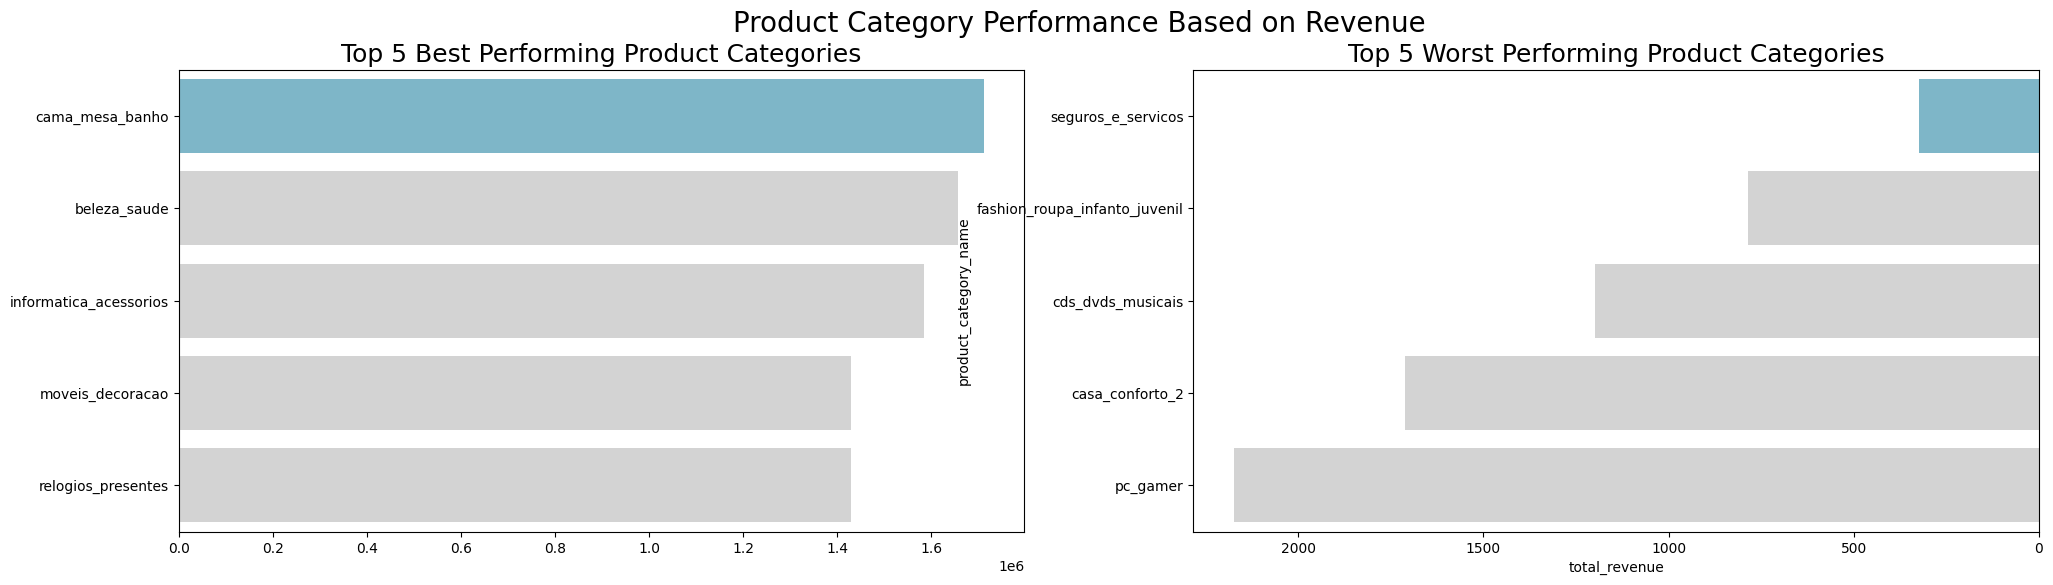

In [417]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Top 5 terbaik
sns.barplot(
    x="total_revenue",
    y="product_category_name",
    data=product_performance_df.sort_values(by="total_revenue", ascending=False).head(5),
    palette=colors,
    ax=ax[0]
)

ax[0].set_title("Top 5 Best Performing Product Categories", fontsize=18)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)

# Top 5 terburuk
sns.barplot(
    x="total_revenue",
    y="product_category_name",
    data=product_performance_df.sort_values(by="total_revenue").head(5),
    palette=colors,
    ax=ax[1]
)

ax[1].set_title("Top 5 Worst Performing Product Categories", fontsize=18)
ax[1].invert_xaxis()

plt.suptitle("Product Category Performance Based on Revenue", fontsize=20)
plt.show()

##### Visualisasi produk terbaik dan terburuk berdasarkan jumlah item terjual

/tmp/ipykernel_16099/3859070014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16099/3859070014.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


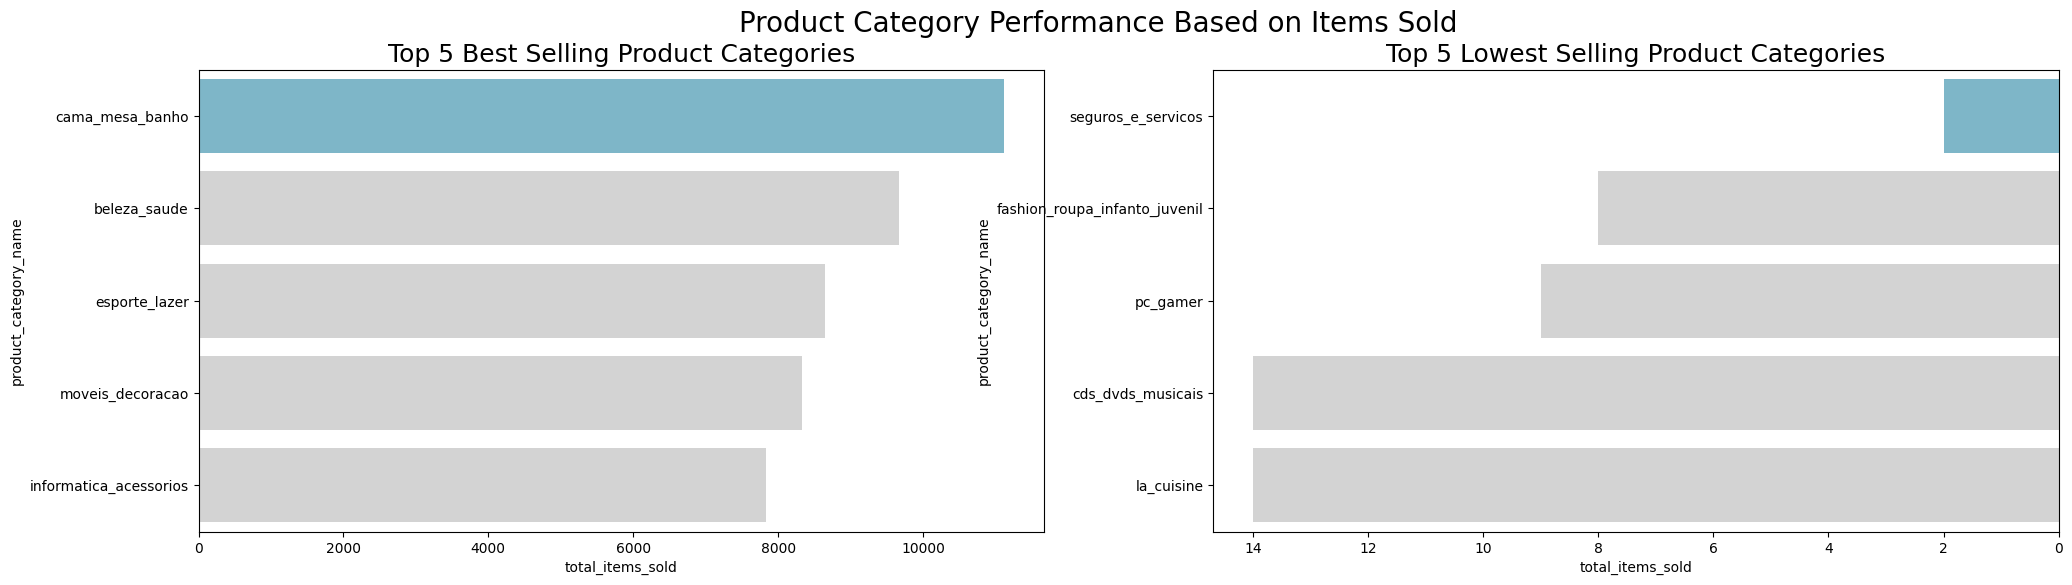

In [418]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

# Top 5 terbaik
sns.barplot(
    x="total_items_sold",
    y="product_category_name",
    data=product_performance_df.sort_values(by="total_items_sold", ascending=False).head(5),
    palette=colors,
    ax=ax[0]
)

ax[0].set_title("Top 5 Best Selling Product Categories", fontsize=18)

# Top 5 terburuk
sns.barplot(
    x="total_items_sold",
    y="product_category_name",
    data=product_performance_df.sort_values(by="total_items_sold").head(5),
    palette=colors,
    ax=ax[1]
)

ax[1].set_title("Top 5 Lowest Selling Product Categories", fontsize=18)
ax[1].invert_xaxis()

plt.suptitle("Product Category Performance Based on Items Sold", fontsize=20)
plt.show()

### Pertanyaan 2: Bagaimana tren penjualan (jumlah order dan revenue) dari waktu ke waktu?

##### Menyiapkan data

In [419]:
# Gunakan data order + payment
orders_analysis_df = orders_df.merge(payment_per_order_df, on="order_id", how="left")

monthly_orders_df = orders_analysis_df.resample(
    rule="M", on="order_purchase_timestamp"
).agg({
    "order_id": "nunique",
    "payment_value": "sum"
}).reset_index()

monthly_orders_df.rename(columns={
    "order_id": "order_count",
    "payment_value": "revenue"
}, inplace=True)

monthly_orders_df["order_month"] = monthly_orders_df["order_purchase_timestamp"].dt.strftime("%b %Y")

monthly_orders_df.head()

/tmp/ipykernel_16099/1430293403.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = orders_analysis_df.resample(


,order_purchase_timestamp,order_count,revenue,order_month
0,2016-09-30,4,252.24,Sep 2016
1,2016-10-31,324,59090.48,Oct 2016
2,2016-11-30,0,0.00,Nov 2016
3,2016-12-31,1,19.62,Dec 2016
4,2017-01-31,800,138488.04,Jan 2017


##### Visualisasi jumlah order per bulan

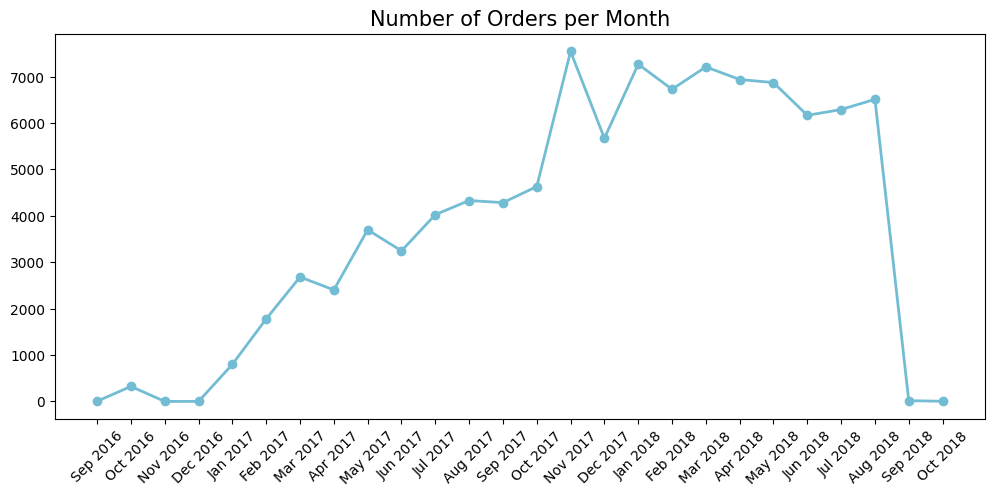

In [420]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders_df["order_month"],
    monthly_orders_df["order_count"],
    marker="o",
    linewidth=2,
    color="#72BCD4"
)

plt.title("Number of Orders per Month", fontsize=15)
plt.xticks(rotation=45)
plt.show()

##### Visualisasi revenue per bulan

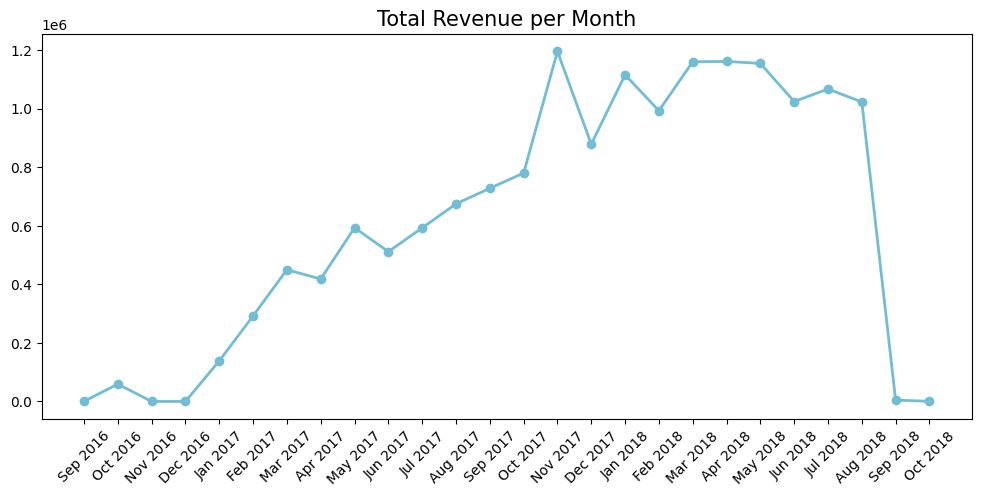

In [421]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders_df["order_month"],
    monthly_orders_df["revenue"],
    marker="o",
    linewidth=2,
    color="#72BCD4"
)

plt.title("Total Revenue per Month", fontsize=15)
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 3: Wilayah (state) mana yang memberikan kontribusi terbesar terhadap total transaksi?

##### Menyiapkan data

In [422]:
state_analysis_df = orders_df.merge(customers_df, on="customer_id", how="left")
state_analysis_df = state_analysis_df.merge(payment_per_order_df, on="order_id", how="left")

state_performance_df = state_analysis_df.groupby(
    by="customer_state"
).agg({
    "order_id": "nunique",
    "payment_value": "sum"
}).reset_index()

state_performance_df.rename(columns={
    "order_id": "order_count",
    "payment_value": "total_revenue"
}, inplace=True)

state_performance_df.sort_values(by="total_revenue", ascending=False).head()

,customer_state,order_count,total_revenue
25,SP,41746,5998226.96
18,RJ,12852,2144379.69
10,MG,11635,1872257.26
22,RS,5466,890898.54
17,PR,5045,811156.38


##### Visualisasi kontribusi wilayah berdasarkan revenue

/tmp/ipykernel_16099/3744886950.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


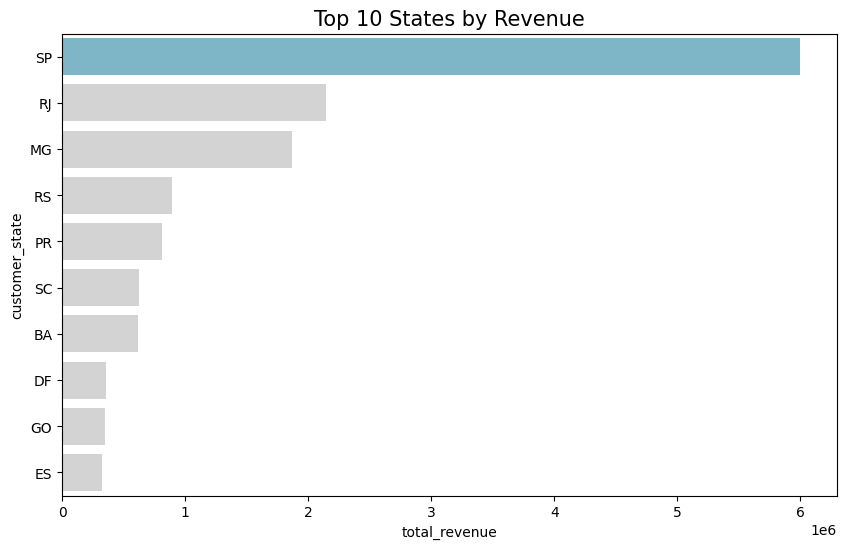

In [423]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="total_revenue",
    y="customer_state",
    data=state_performance_df.sort_values(by="total_revenue", ascending=False).head(10),
    palette=["#72BCD4"] + ["#D3D3D3"]*9
)

plt.title("Top 10 States by Revenue", fontsize=15)
plt.show()

##### Visualisasi kontribusi wilayah berdasarkan jumlah order

/tmp/ipykernel_16099/3067048638.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


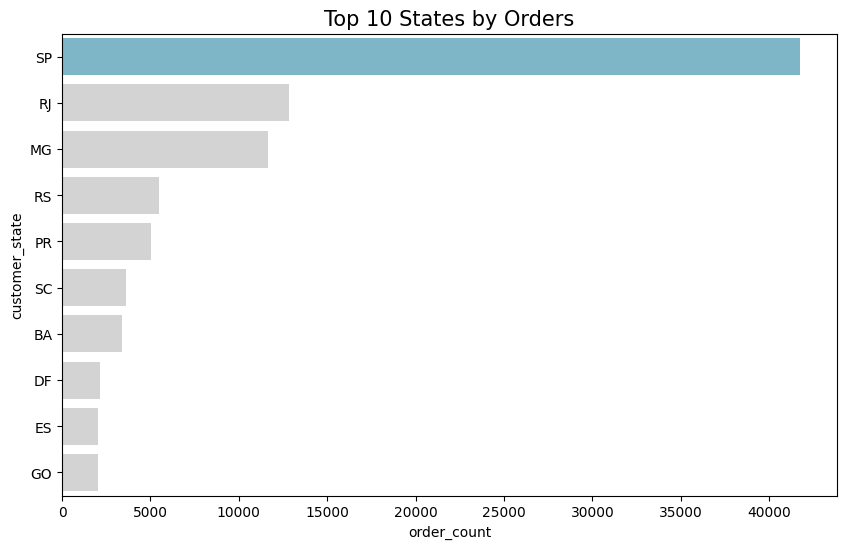

In [424]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="order_count",
    y="customer_state",
    data=state_performance_df.sort_values(by="order_count", ascending=False).head(10),
    palette=["#72BCD4"] + ["#D3D3D3"]*9
)

plt.title("Top 10 States by Orders", fontsize=15)
plt.show()

**Insight:**

1. Produk Terbaik & Terburuk
- Kategori cama_mesa_banho mendominasi baik dari sisi revenue maupun jumlah penjualan, sementara kategori seperti cds_dvds_musicais dan pc_gamer menunjukkan performa terendah. Hal ini menunjukkan distribusi permintaan yang tidak merata antar kategori.

2. Tren Penjualan (Order & Revenue)
- Kategori cama_mesa_banho mendominasi baik dari sisi revenue maupun jumlah penjualan, sementara kategori seperti cds_dvds_musicais dan pc_gamer menunjukkan performa terendah. Hal ini menunjukkan distribusi permintaan yang tidak merata antar kategori.

3. Kontribusi Wilayah
- State *SP (São Paulo)* memberikan kontribusi revenue yang paling besar secara signifikan dibandingkan wilayah lainnya.
- State seperti *RJ* dan *MG* juga memberikan kontribusi yang cukup besar, namun masih jauh di bawah SP.

## RFM Analysis

##### Menyiapkan data RFM

In [425]:
# Payment per order
payment_per_order_df = order_payments_df.groupby(
    "order_id", as_index=False
)["payment_value"].sum()

# Gabungkan orders + customers + payment
rfm_base_df = orders_df.merge(customers_df, on="customer_id", how="left")
rfm_base_df = rfm_base_df.merge(payment_per_order_df, on="order_id", how="left")

rfm_base_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62


##### Membuat RFM Table

In [426]:
rfm_df = rfm_base_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max",  # terakhir transaksi
    "order_id": "nunique",              # jumlah transaksi
    "payment_value": "sum"              # total pengeluaran
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

rfm_df.head()

,customer_id,max_order_timestamp,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01


##### Menghitung Recency

In [427]:
rfm_df["max_order_timestamp"] = pd.to_datetime(rfm_df["max_order_timestamp"])

recent_date = rfm_df["max_order_timestamp"].max()

rfm_df["recency"] = (recent_date - rfm_df["max_order_timestamp"]).dt.days

rfm_df.head()

,customer_id,max_order_timestamp,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,337
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,458
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,596
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,427
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,198


##### Drop kolom timestamp

In [428]:
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,337
1,000161a058600d5901f007fab4c27140,1,67.41,458
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,596
3,0002414f95344307404f0ace7a26f1d5,1,179.35,427
4,000379cdec625522490c315e70c7a9fb,1,107.01,198


##### Statistik deskriptif

In [429]:
rfm_df.describe()

,frequency,monetary,recency
count,99441.0,99441.000000,99441.000000
mean,1.0,160.988648,289.900192
std,0.0,221.950728,153.667316
min,1.0,0.000000,0.000000
25%,1.0,62.010000,166.000000
50%,1.0,105.290000,271.000000
75%,1.0,176.970000,400.000000
max,1.0,13664.080000,772.000000


##### Melihat Top Customer

In [430]:
rfm_df.sort_values(by="recency", ascending=True).head(5)

,customer_id,frequency,monetary,recency
63970,a4b417188addbc05b26b72d5e44837a1,1,89.71,0
51713,856336203359aa6a61bf3826f7d84c49,1,222.03,0
29531,4c2ec60c29d10c34bd49cb88aa85cfc4,1,197.55,13
74611,bf6181a85bbb4115736c0a8db1a53be3,1,80.38,16
15595,2823ffda607a2316375088e0d00005ec,1,137.03,18


In [431]:
rfm_df.sort_values(by="frequency", ascending=False).head(5)

,customer_id,frequency,monetary,recency
99440,ffffe8b65bbe3087b653a978c870db99,1,18.37,383
99424,fff5169e583fd07fac9fec88962f189d,1,152.77,158
99423,fff4fdd0de70a51d4e0f57a4c1c6bfae,1,21.04,191
99422,fff4f0c85a4d710abe06599e1ed08a42,1,89.70,571
99421,fff415b4c72e09483a25c15108c65d31,1,84.57,327


In [432]:
rfm_df.sort_values(by="monetary", ascending=False).head(5)

,customer_id,frequency,monetary,recency
8546,1617b1357756262bfa56ab541c47bc16,1,13664.08,383
91985,ec5b2ba62e574342386871631fafd3fc,1,7274.88,94
77522,c6e2731c5b391845f6800c97401a43a9,1,6929.31,611
95124,f48d464a0baaea338cb25f816991ab1f,1,6922.21,83
24771,3fd6777bbce08a352fddd04e4a7cc8f6,1,6726.66,510


###### Visualisasi Top Customer berdasarkan RFM

/tmp/ipykernel_16099/4041972687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16099/4041972687.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_16099/4041972687.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


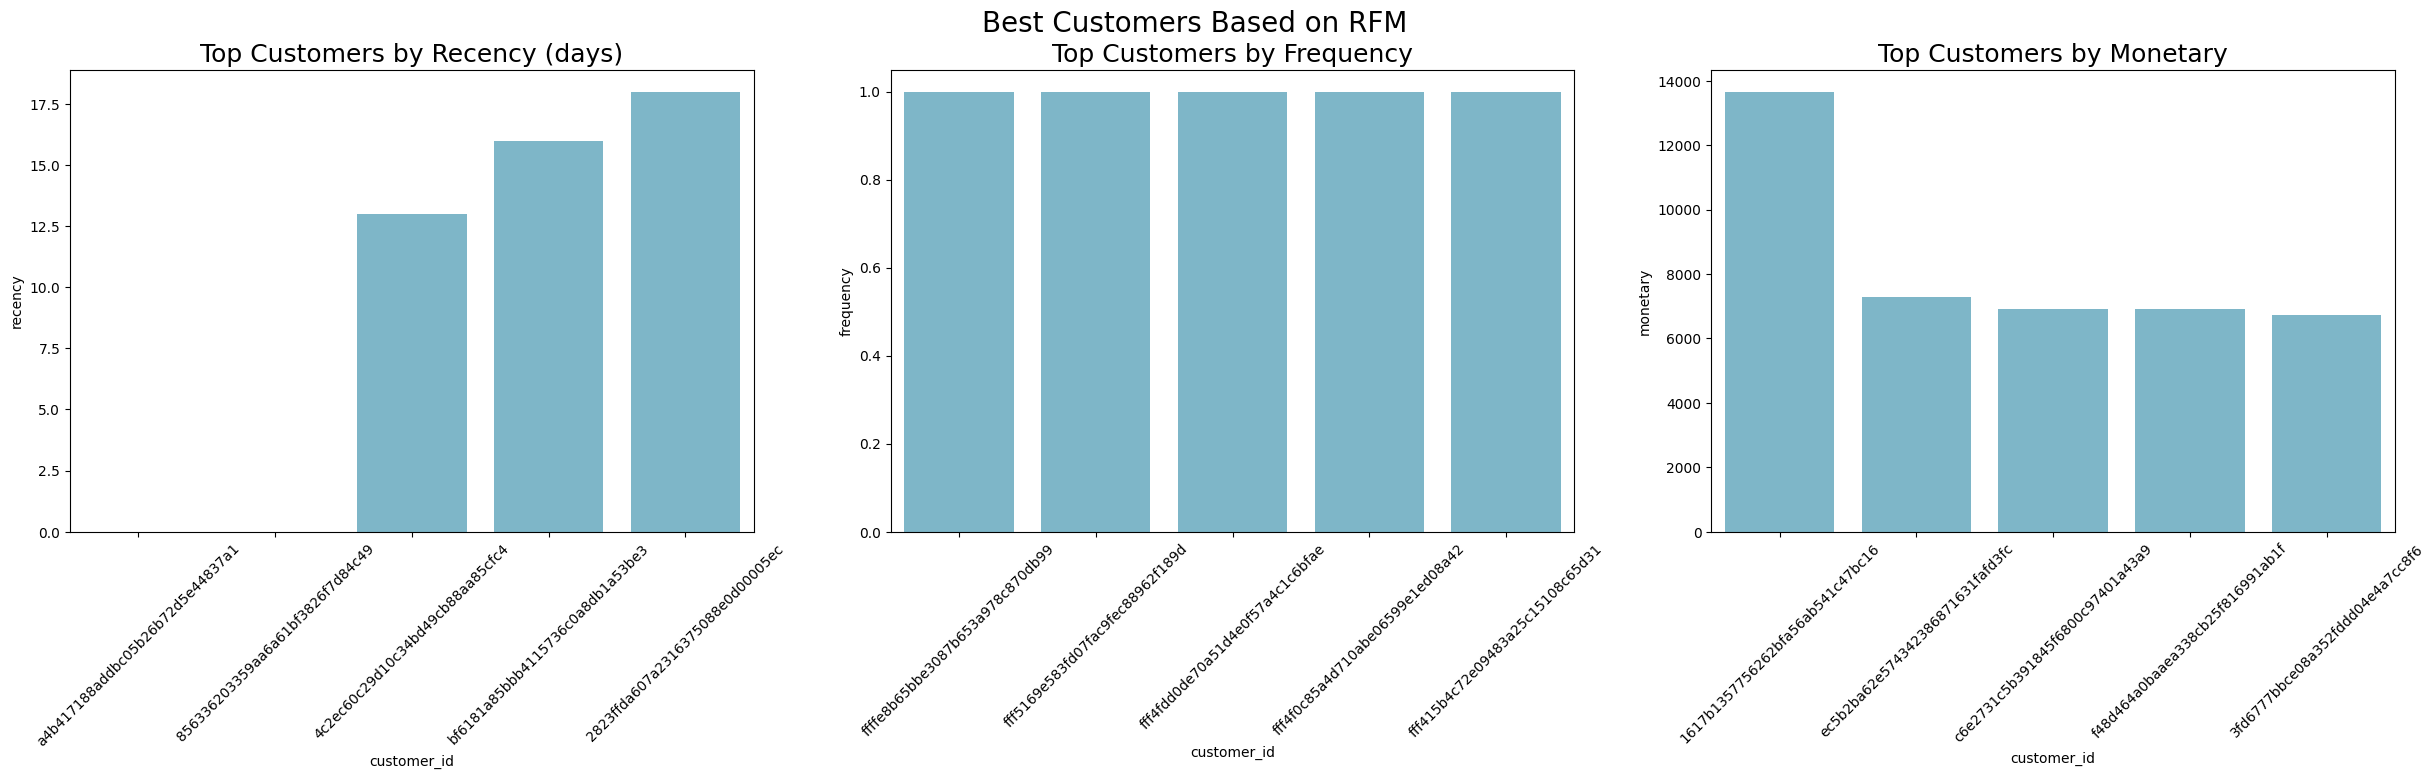

In [433]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4"] * 5

# Recency
sns.barplot(
    y="recency",
    x="customer_id",
    data=rfm_df.sort_values(by="recency").head(5),
    palette=colors,
    ax=ax[0]
)
ax[0].set_title("Top Customers by Recency (days)", fontsize=18)
ax[0].tick_params(axis='x', rotation=45)

# Frequency
sns.barplot(
    y="frequency",
    x="customer_id",
    data=rfm_df.sort_values(by="frequency", ascending=False).head(5),
    palette=colors,
    ax=ax[1]
)
ax[1].set_title("Top Customers by Frequency", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# Monetary
sns.barplot(
    y="monetary",
    x="customer_id",
    data=rfm_df.sort_values(by="monetary", ascending=False).head(5),
    palette=colors,
    ax=ax[2]
)
ax[2].set_title("Top Customers by Monetary", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customers Based on RFM", fontsize=20)
plt.show()

##### Menghitung RFM Score

In [434]:
rfm_df["r_rank"] = rfm_df["recency"].rank(ascending=False)
rfm_df["f_rank"] = rfm_df["frequency"].rank(ascending=True)
rfm_df["m_rank"] = rfm_df["monetary"].rank(ascending=True)

##### Normalisasi ranking

In [435]:
rfm_df["r_rank_norm"] = (rfm_df["r_rank"] / rfm_df["r_rank"].max()) * 100
rfm_df["f_rank_norm"] = (rfm_df["f_rank"] / rfm_df["f_rank"].max()) * 100
rfm_df["m_rank_norm"] = (rfm_df["m_rank"] / rfm_df["m_rank"].max()) * 100

rfm_df.drop(columns=["r_rank", "f_rank", "m_rank"], inplace=True)

##### Menghitung RFM Score Final

In [436]:
rfm_df["RFM_score"] = (
    0.15 * rfm_df["r_rank_norm"] +
    0.28 * rfm_df["f_rank_norm"] +
    0.57 * rfm_df["m_rank_norm"]
)

rfm_df["RFM_score"] *= 0.05
rfm_df = rfm_df.round(2)

rfm_df.head()

,customer_id,frequency,monetary,recency,r_rank_norm,f_rank_norm,m_rank_norm,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,337,34.49,100.0,54.26,3.20
1,000161a058600d5901f007fab4c27140,1,67.41,458,16.92,100.0,29.04,2.35
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,596,2.88,100.0,78.75,3.67
3,0002414f95344307404f0ace7a26f1d5,1,179.35,427,21.23,100.0,75.57,3.71
4,000379cdec625522490c315e70c7a9fb,1,107.01,198,67.25,100.0,50.90,3.36


##### Segmentasi Customer

In [437]:
rfm_df["customer_segment"] = np.where(
    rfm_df["RFM_score"] > 4.5, "Top Customers",
    np.where(
        rfm_df["RFM_score"] > 4, "High Value Customers",
        np.where(
            rfm_df["RFM_score"] > 3, "Medium Value Customers",
            np.where(
                rfm_df["RFM_score"] > 1.6, "Low Value Customers",
                "Lost Customers"
            )
        )
    )
)

##### Visualisasi Segmentasi Customer

In [438]:
customer_segment_df = rfm_df.groupby(
    by="customer_segment", as_index=False
)["customer_id"].nunique()

customer_segment_df

,customer_segment,customer_id
0,High Value Customers,16187
1,Lost Customers,1072
2,Low Value Customers,41901
3,Medium Value Customers,34701
4,Top Customers,5580


In [439]:
customer_segment_df["customer_segment"] = pd.Categorical(
    customer_segment_df["customer_segment"],
    categories=[
        "Lost Customers",
        "Low Value Customers",
        "Medium Value Customers",
        "High Value Customers",
        "Top Customers"
    ],
    ordered=True
)

/tmp/ipykernel_16099/1188565982.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


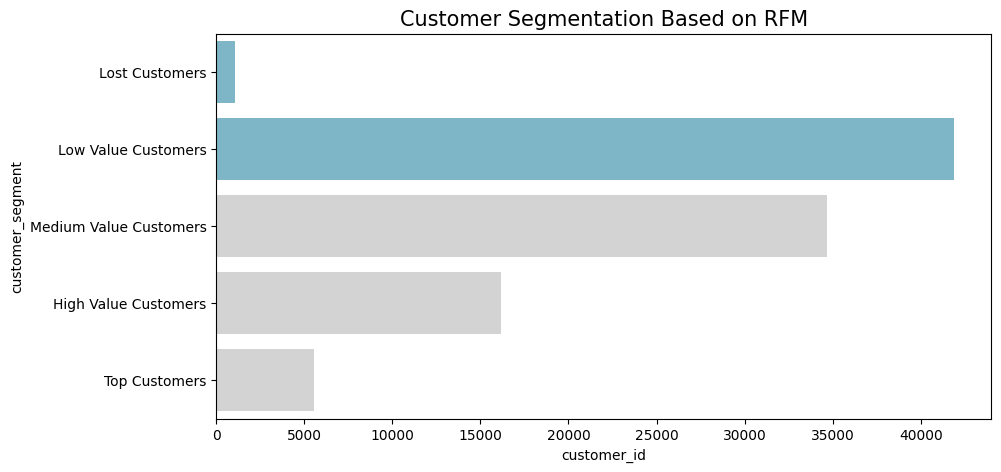

In [440]:
plt.figure(figsize=(10,5))

colors = ["#72BCD4", "#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="customer_id",
    y="customer_segment",
    data=customer_segment_df.sort_values(by="customer_segment", ascending=False),
    palette=colors
)

plt.title("Customer Segmentation Based on RFM", fontsize=15)
plt.show()

**Insight:**
- Berdasarkan analisis RFM, sebagian besar pelanggan berada pada kategori **Low value customers (41.560 pelanggan)** dan **Medium value customers (34.424 pelanggan)**. Hal ini menunjukkan bahwa mayoritas pelanggan memiliki frekuensi transaksi dan nilai pembelian yang relatif rendah hingga sedang.
- Jumlah **High value customers (16.012 pelanggan)** dan **Top customers (5.600 pelanggan)** relatif lebih sedikit, namun kelompok ini memiliki kontribusi besar terhadap revenue sehingga perlu dipertahankan melalui strategi loyalitas.
- Terdapat sekitar **1.070 pelanggan yang masuk kategori Lost customers**, yang menunjukkan adanya pelanggan yang sudah lama tidak melakukan transaksi dan berpotensi untuk direaktivasi.
- Visualisasi RFM menunjukkan bahwa pelanggan dengan nilai monetary tertinggi memberikan kontribusi revenue yang jauh lebih besar dibandingkan pelanggan lainnya, meskipun jumlahnya lebih sedikit.
- Distribusi ini mengindikasikan bahwa bisnis masih memiliki peluang besar untuk meningkatkan revenue dengan cara mengonversi pelanggan dari kategori Low dan Medium menjadi High value customers.

## Conclusion

### 1. Kategori produk terbaik dan terburuk
Berdasarkan hasil analisis, kategori produk *cama_mesa_banho* merupakan kategori dengan performa penjualan terbaik karena menghasilkan revenue tertinggi. Selain itu, kategori seperti *beleza_saude* dan *informatica_acessorios* juga menunjukkan kontribusi yang signifikan terhadap total penjualan.  
Sebaliknya, kategori seperti *seguros_e_servicos* dan *pc_gamer* memiliki performa yang paling rendah. Hal ini menunjukkan bahwa terdapat perbedaan permintaan yang cukup besar antar kategori produk, sehingga perusahaan perlu fokus pada kategori unggulan serta mengevaluasi kategori dengan performa rendah.

---

### 2. Tren penjualan dari waktu ke waktu
Analisis menunjukkan bahwa tren penjualan mengalami peningkatan dari tahun 2017 hingga mencapai puncaknya pada awal hingga pertengahan tahun 2018. Meskipun terdapat fluktuasi, performa penjualan tetap berada pada level yang relatif tinggi.  
Penurunan drastis pada periode terakhir kemungkinan disebabkan oleh data yang belum lengkap. Secara keseluruhan, tren ini menunjukkan bahwa bisnis mengalami pertumbuhan yang positif dalam periode yang dianalisis.

---

### 3. Kontribusi wilayah terhadap penjualan
Wilayah *SP (São Paulo)* merupakan kontributor terbesar terhadap total revenue perusahaan, diikuti oleh wilayah seperti *RJ* dan *MG*. Hal ini menunjukkan bahwa sebagian besar transaksi terkonsentrasi pada wilayah tertentu.  
Dengan demikian, wilayah dengan kontribusi tinggi dapat dianggap sebagai pasar utama, sementara wilayah dengan kontribusi rendah memiliki potensi untuk dikembangkan melalui strategi pemasaran atau ekspansi bisnis.

---

### Kesimpulan Umum
Secara keseluruhan, performa bisnis dipengaruhi oleh kombinasi faktor kategori produk, waktu, dan wilayah. Perusahaan dapat meningkatkan kinerja dengan:
- Memfokuskan strategi pada kategori produk unggulan
- Memanfaatkan momentum tren penjualan
- Mengoptimalkan wilayah dengan kontribusi tinggi serta mengembangkan wilayah dengan potensi pertumbuhan

### Menyimpan Data untuk Dashboard

In [441]:
payment_per_order_df = order_payments_df.groupby("order_id", as_index=False)["payment_value"].sum()

dashboard_df = orders_df.merge(customers_df, on="customer_id", how="left")
dashboard_df = dashboard_df.merge(payment_per_order_df, on="order_id", how="left")

dashboard_df = dashboard_df[[
    "order_id",
    "customer_id",
    "customer_state",
    "order_purchase_timestamp",
    "payment_value"
]]

dashboard_df.to_csv("dashboard/main_data.csv", index=False)

In [442]:
product_performance_df.to_csv("dashboard/product_performance.csv", index=False)
customer_segment_df.to_csv("dashboard/customer_segment.csv", index=False)